In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [1]:
from openagri_benchmark.postprocessing.utils import (
    read_benchmark_results,
)

In [3]:
raw_results = read_benchmark_results('stress_test')

In [69]:
import json
# raw_results.pop('high')
# print(json.dumps(raw_results, indent=4))

In [13]:
data = []

for workload, services in raw_results.items():
    for service_name, evaluations in services.items():
        for eval_key, eval_data in evaluations.items():
            result = eval_data['result']
            eval_id = result['id']
            
            for task_name, task_data in result[service_name]['tasks'].items():
                s_container_name, db_container_name = (None, None)
                for c_i, c_name in enumerate(task_data['stats'].keys()):
                    if c_name.endswith('_db'):
                        db_container_name = c_name
                    else:
                        s_container_name = c_name

                s_cpu = task_data['stats'][s_container_name]['cpu_avg']
                s_mem = task_data['stats'][s_container_name]['mem_avg']
                db_cpu = task_data['stats'][db_container_name]['cpu_avg']
                db_mem = task_data['stats'][db_container_name]['mem_avg']
                row = {
                    'workload': workload,
                    'service': service_name,
                    'eval_id': eval_id,
                    'task': task_name,
                    'P99_RTT': task_data['request_times_p99'],
                    'S_CPU%': s_cpu,
                    'S_MEM%': s_mem,
                    'DB_CPU%': db_cpu,
                    'DB_MEM%': db_mem
                }
                data.append(row)

df = pd.DataFrame(data)

In [14]:
df

,workload,service,eval_id,task,P99_RTT,S_CPU%,S_MEM%,DB_CPU%,DB_MEM%
0,low,pestanddisease,stress_test.pestanddisease_low_2026-08-12-151656,register_disease,0.041391,2.805000,0.350,0.695000,0.090000
1,low,pestanddisease,stress_test.pestanddisease_low_2026-08-12-151656,list_disease,0.027102,3.380000,0.350,0.755000,0.090000
2,low,pestanddisease,stress_test.pestanddisease_low_2026-08-12-151656,upload_data,1.934757,89.765000,0.635,24.040000,0.130000
3,low,pestanddisease,stress_test.pestanddisease_low_2026-08-12-151656,get_parcel_data,0.103780,16.950000,0.690,2.420000,0.140000
4,low,pestanddisease,stress_test.pestanddisease_low_2026-08-12-151656,calculate_gdd,0.044730,10.610000,0.690,2.840000,0.150000
5,low,pestanddisease,stress_test.pestanddisease_low_2026-08-12-151656,calculate_risk,0.101836,17.310000,0.690,2.690000,0.150000
6,low,pestanddisease,stress_test.pestanddisease_low_2026-08-12-151656,fuzzy_risk_calculate,0.099261,9.120000,0.690,2.240000,0.150000
7,low,pestanddisease,stress_test.pestanddisease_low_2026-08-12-151619,register_disease,0.039367,4.355000,0.350,1.110000,0.090000
8,low,pestanddisease,stress_test.pestanddisease_low_2026-08-12-151619,list_disease,0.027626,3.435000,0.350,0.725000,0.090000
9,low,pestanddisease,stress_test.pestanddisease_low_2026-08-12-151619,upload_data,1.683300,80.720000,0.585,17.860000,0.120000


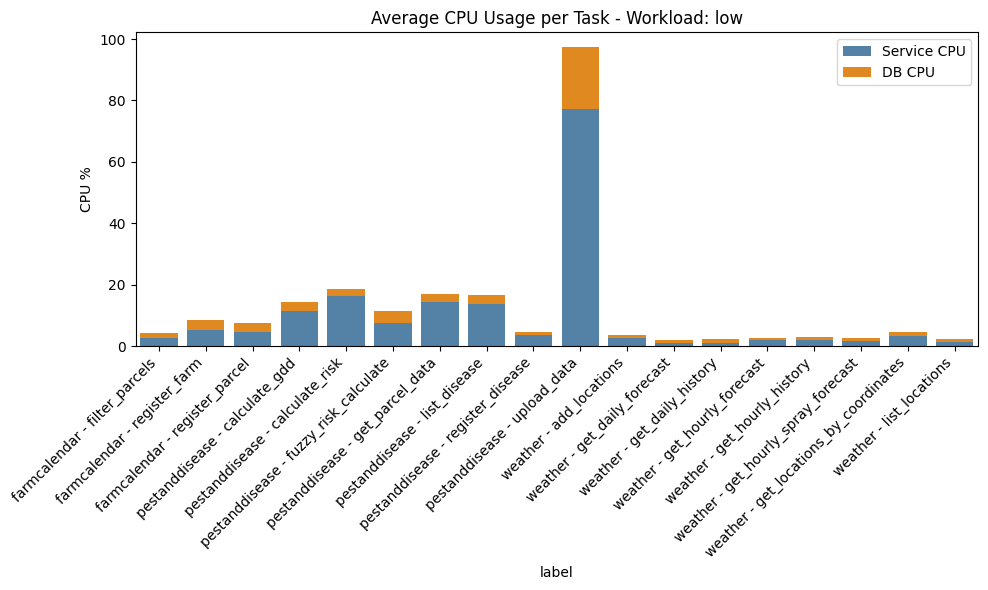

In [17]:
# Aggregate CPU averages per workload, service, and task
df_cpu = df.groupby(['workload', 'service', 'task'])[['S_CPU%', 'DB_CPU%']].mean().reset_index()

# Plot for each workload
for workload in df_cpu['workload'].unique():
    wl_data = df_cpu[df_cpu['workload'] == workload].copy()
    wl_data['label'] = wl_data['service'] + ' - ' + wl_data['task']
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='label', y='S_CPU%', data=wl_data, color='steelblue', label='Service CPU')
    sns.barplot(x='label', y='DB_CPU%', data=wl_data, color='darkorange', label='DB CPU',
                bottom=wl_data['S_CPU%'])
    plt.title(f'Average CPU Usage per Task - Workload: {workload}')
    plt.ylabel('CPU %')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()

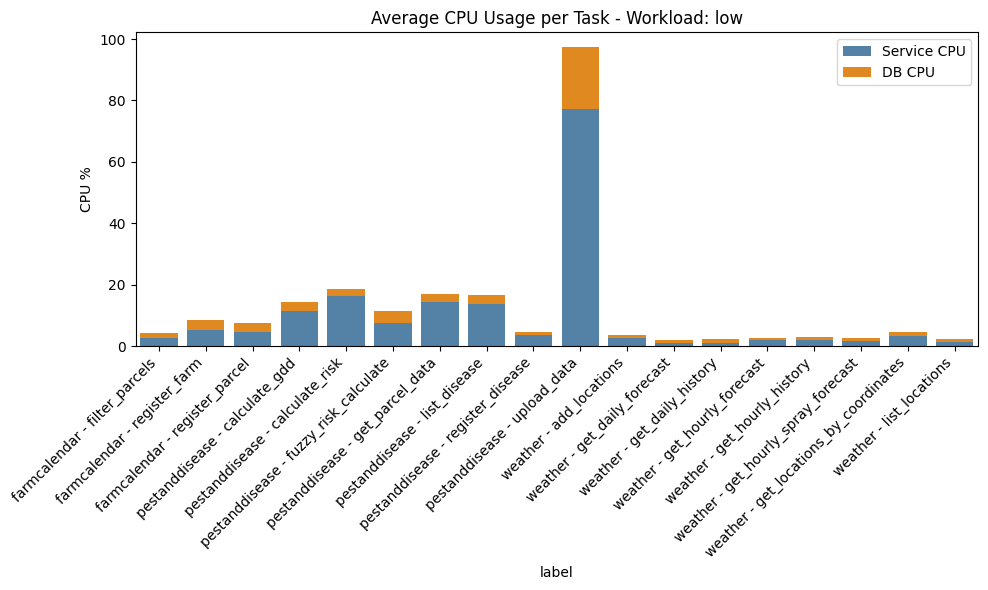

In [18]:
# Aggregate CPU averages per workload, service, and task
df_cpu = df.groupby(['workload', 'service', 'task'])[['S_CPU%', 'DB_CPU%']].mean().reset_index()

# Plot for each workload
for workload in df_cpu['workload'].unique():
    wl_data = df_cpu[df_cpu['workload'] == workload].copy()
    wl_data['label'] = wl_data['service'] + ' - ' + wl_data['task']
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='label', y='S_CPU%', data=wl_data, color='steelblue', label='Service CPU')
    sns.barplot(x='label', y='DB_CPU%', data=wl_data, color='darkorange', label='DB CPU',
                bottom=wl_data['S_CPU%'])
    plt.title(f'Average CPU Usage per Task - Workload: {workload}')
    plt.ylabel('CPU %')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()

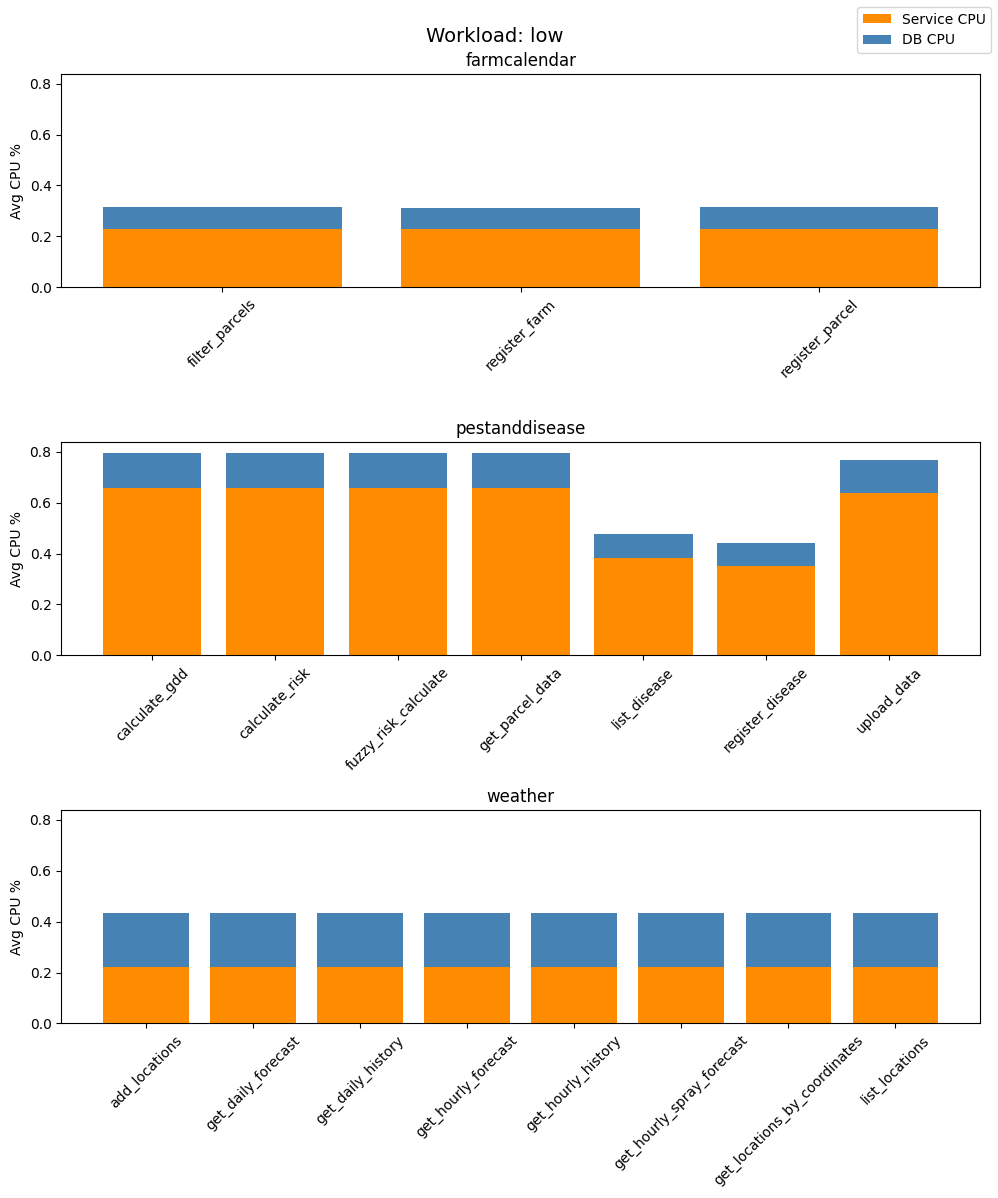

In [38]:
df_cpu = df.groupby(['workload', 'service', 'task'])[['S_CPU%', 'DB_CPU%']].mean().reset_index()
df_mem = df.groupby(['workload', 'service', 'task'])[['S_MEM%', 'DB_MEM%']].mean().reset_index()

for workload in df_mem['workload'].unique():
    # wl_data = df_cpu[df_cpu['workload'] == workload]
    wl_data = df_mem[df_mem['workload'] == workload]
    services = wl_data['service'].unique()
    n_services = len(services)

    # sharey=True  <-- ensures identical y-scale across all subplots
    fig, axes = plt.subplots(n_services, 1, figsize=(10, 4 * n_services), sharey=True)

    # for ax, service in zip(axes, services):
    #     s_data = wl_data[wl_data['service'] == service]
    #     ax.bar(s_data['task'], s_data['S_CPU%'], label='Service CPU', color='darkorange')
    #     ax.bar(s_data['task'], s_data['DB_CPU%'], bottom=s_data['S_CPU%'], label='DB CPU', color='steelblue')
    #     ax.set_title(service)
    #     ax.set_ylabel('Avg CPU %')
    #     ax.tick_params(axis='x', rotation=45)
    
    for ax, service in zip(axes, services):
        s_data = wl_data[wl_data['service'] == service]
        ax.bar(s_data['task'], s_data['S_MEM%'], label='Service CPU', color='darkorange')
        ax.bar(s_data['task'], s_data['DB_MEM%'], bottom=s_data['S_MEM%'], label='DB CPU', color='steelblue')
        ax.set_title(service)
        ax.set_ylabel('Avg CPU %')
        ax.tick_params(axis='x', rotation=45)

    # Common legend for the whole figure
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right')
    fig.suptitle(f'Workload: {workload}', fontsize=14)
    plt.tight_layout()
    plt.show()

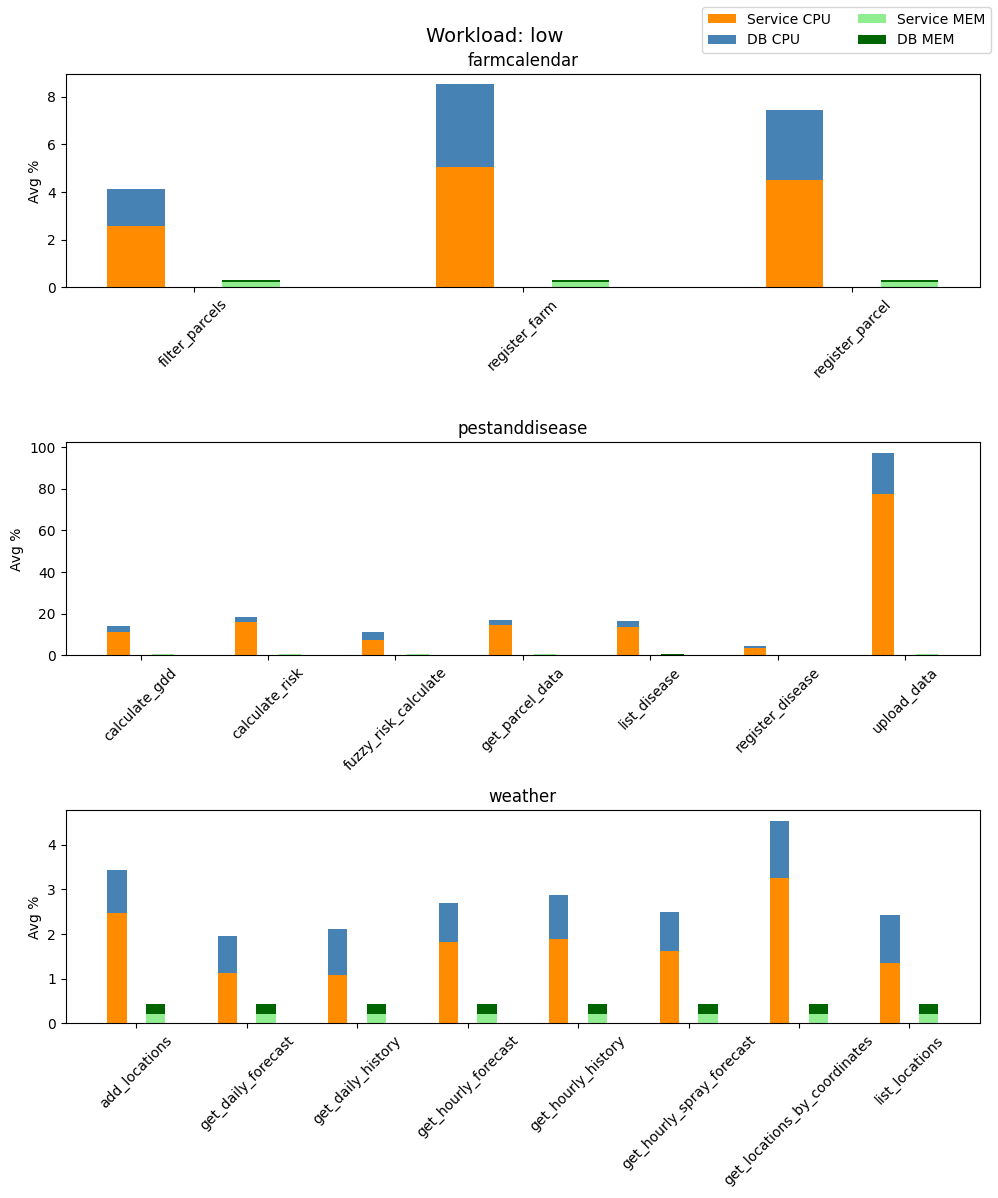

In [35]:
import numpy as np

# Compute averages for CPU and memory
df_cpu = df.groupby(['workload', 'service', 'task'])[['S_CPU%', 'DB_CPU%']].mean().reset_index()
df_mem = df.groupby(['workload', 'service', 'task'])[['S_MEM%', 'DB_MEM%']].mean().reset_index()

for workload in df_cpu['workload'].unique():
    wl_cpu = df_cpu[df_cpu['workload'] == workload]
    wl_mem = df_mem[df_mem['workload'] == workload]
    services = wl_cpu['service'].unique()
    n_services = len(services)

    fig, axes = plt.subplots(n_services, 1, figsize=(10, 4 * n_services), sharey=False)
    if n_services == 1:
        axes = [axes]

    for ax, service in zip(axes, services):
        s_cpu = wl_cpu[wl_cpu['service'] == service].set_index('task')
        s_mem = wl_mem[wl_mem['service'] == service].set_index('task')
        tasks = s_cpu.index.tolist()
        x = np.arange(len(tasks))
        width = 0.35   # total width for one task group

        # CPU stack (left side of the group)
        ax.bar(x - width/2, s_cpu.loc[tasks, 'S_CPU%'], width/2,
               label='Service CPU', color='darkorange')
        ax.bar(x - width/2, s_cpu.loc[tasks, 'DB_CPU%'], width/2,
               bottom=s_cpu.loc[tasks, 'S_CPU%'], label='DB CPU', color='steelblue')

        # MEM stack (right side of the group)
        ax.bar(x + width/2, s_mem.loc[tasks, 'S_MEM%'], width/2,
               label='Service MEM', color='lightgreen')
        ax.bar(x + width/2, s_mem.loc[tasks, 'DB_MEM%'], width/2,
               bottom=s_mem.loc[tasks, 'S_MEM%'], label='DB MEM', color='darkgreen')

        ax.set_xticks(x)
        ax.set_xticklabels(tasks, rotation=45)
        ax.set_title(service)
        ax.set_ylabel('Avg %')

    # Single legend for the whole figure
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', ncol=2)
    fig.suptitle(f'Workload: {workload}', fontsize=14)
    plt.tight_layout()
    plt.show()

In [51]:


def plot_resource(df, resource='cpu'):
    """
    Plot stacked bar charts of CPU or memory usage per task, grouped by service.
    """
    # Pick the right columns and labels
    if resource == 'cpu':
        s_col, db_col = 'S_CPU%', 'DB_CPU%'
        label = 'Avg CPU %'
        color_s, color_db = 'darkorange', 'steelblue'
        s_leg, db_leg = 'Service CPU', 'DB CPU'
    else:  # mem
        s_col, db_col = 'S_MEM%', 'DB_MEM%'
        label = 'Avg MEM %'
        color_s, color_db = 'lightgreen', 'darkgreen'
        s_leg, db_leg = 'Service MEM', 'DB MEM'
    
    # Aggregate means per workload, service, task for the chosen resource
    df_agg = df.groupby(['workload', 'service', 'task'])[[s_col, db_col]].mean().reset_index()
    
    for workload in df_agg['workload'].unique():
        wl_data = df_agg[df_agg['workload'] == workload]
        services = wl_data['service'].unique()
        n_services = len(services)
        
        # sharey=True → identical vertical scale across all subplots
        fig, axes = plt.subplots(n_services, 1, figsize=(4, 4 * n_services), sharey=True)
        
        for ax, service in zip(axes, services):
            s_data = wl_data[wl_data['service'] == service]
            ax.bar(s_data['task'], s_data[s_col],
                   label=s_leg, color=color_s)
            ax.bar(s_data['task'], s_data[db_col],
                   bottom=s_data[s_col], label=db_leg, color=color_db)
            ax.set_title(service)
            ax.set_ylabel(label)
            ax.tick_params(axis='x', rotation=90)
        
        # Common legend for the whole figure
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center')
        fig.suptitle(f'{resource.upper()} Usage – Workload: {workload}', fontsize=14)
        plt.tight_layout()
        plt.show()

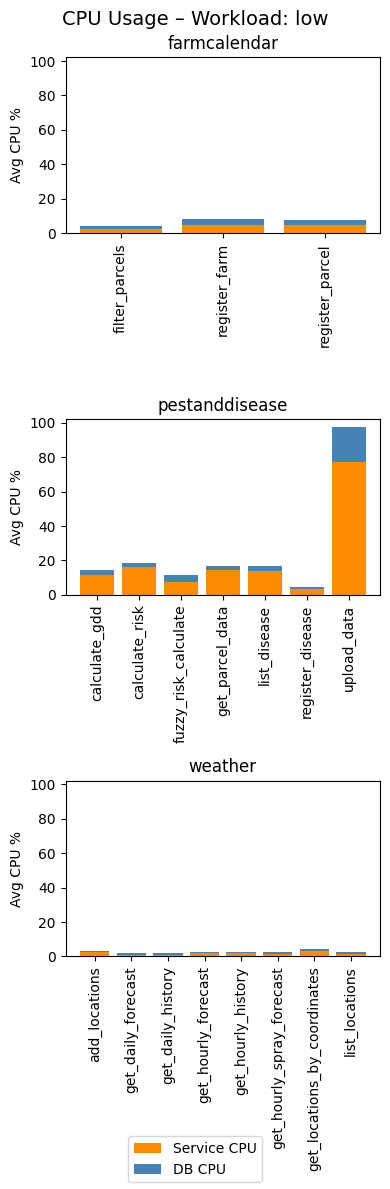

In [52]:
plot_resource(df, 'cpu')

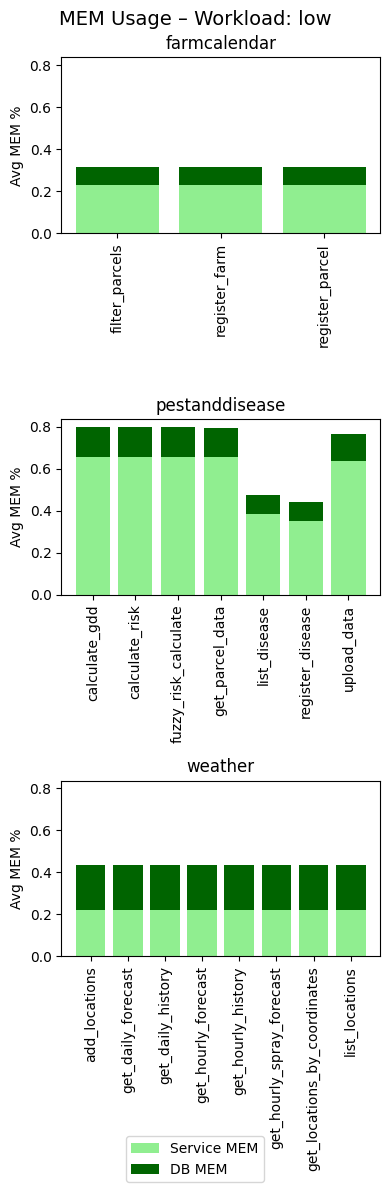

In [53]:
plot_resource(df, 'mem') 

# This one below seems like a nice view, use it

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_resource(df):
    """
    Plot stacked CPU and memory bars per task, grouped by service.
    One row per service: left column = CPU, right column = memory.
    """
    # Aggregate means for CPU and memory
    cpu_agg = df.groupby(['workload', 'service', 'task'])[['S_CPU%', 'DB_CPU%']].mean().reset_index()
    mem_agg = df.groupby(['workload', 'service', 'task'])[['S_MEM%', 'DB_MEM%']].mean().reset_index()

    for workload in cpu_agg['workload'].unique():
        cpu_wl = cpu_agg[cpu_agg['workload'] == workload]
        mem_wl = mem_agg[mem_agg['workload'] == workload]
        services = cpu_wl['service'].unique()
        n_services = len(services)

        # 2 columns: CPU left, memory right; sharey per column
        fig, axes = plt.subplots(n_services, 2,
                                 figsize=(10, 4 * n_services),
                                 sharey='col')
        # axes is 2D: axes[row, 0] = CPU, axes[row, 1] = memory

        for i, service in enumerate(services):
            # --- CPU subplot (left) ---
            cpu_data = cpu_wl[cpu_wl['service'] == service]
            ax_cpu = axes[i, 0]
            ax_cpu.bar(cpu_data['task'], cpu_data['S_CPU%'],
                       label='Service CPU', color='darkorange')
            ax_cpu.bar(cpu_data['task'], cpu_data['DB_CPU%'],
                       bottom=cpu_data['S_CPU%'], label='DB CPU', color='steelblue')
            ax_cpu.set_title(f'{service} CPU')
            ax_cpu.set_ylabel('Avg CPU %')
            ax_cpu.tick_params(axis='x', rotation=90)

            # --- Memory subplot (right) ---
            mem_data = mem_wl[mem_wl['service'] == service]
            ax_mem = axes[i, 1]
            ax_mem.bar(mem_data['task'], mem_data['S_MEM%'],
                       label='Service MEM', color='lightgreen')
            ax_mem.bar(mem_data['task'], mem_data['DB_MEM%'],
                       bottom=mem_data['S_MEM%'], label='DB MEM', color='darkgreen')
            ax_mem.set_title(f'{service} MEM')
            ax_mem.set_ylabel('Avg MEM % (Axis zoomed in)')
            ax_mem.tick_params(axis='x', rotation=90)

        # Unified legend for all four components
        legend_elements = [
            Patch(facecolor='darkorange', label='Service CPU'),
            Patch(facecolor='steelblue',   label='DB CPU'),
            Patch(facecolor='lightgreen',  label='Service MEM'),
            Patch(facecolor='darkgreen',   label='DB MEM')
        ]
        fig.legend(handles=legend_elements, loc='lower center', ncol=4)
        fig.suptitle(f'Resource Usage – Workload: {workload}', fontsize=14)
        plt.tight_layout()
        plt.show()

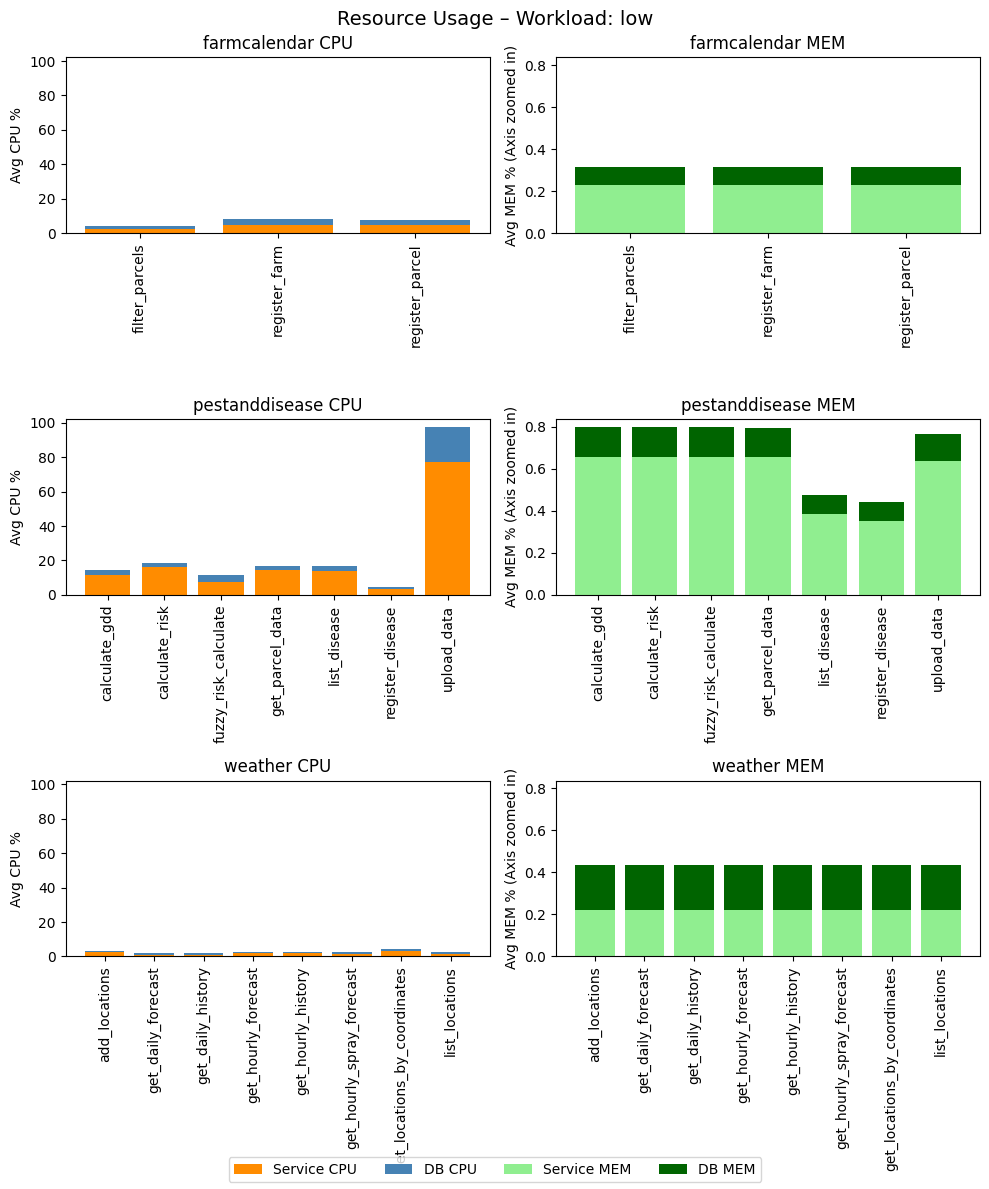

In [68]:
plot_resource(df)